# Project Objective (Goal):

## The main objective of this machine learning project is to predict whether a credit card transaction is fraudulent or legitimate based on transaction-related features and patterns.

## This helps financial institutions:

### 1. Detect fraudulent transactions quickly and accurately.

### 2. Reduce financial losses caused by unauthorized activities.

### 3. Improve transaction security and customer trust.
- **Problem Type**: Binary Classification
- **Target Variable**: `is_fraud` (0 = Legitimate, 1 = Fraud)
- **Goal**: Build a high-accuracy model that can detect fraud with minimal false positives and false negatives

#### Made by Karan Upadhyay
#### Guided by Sameer Warsolkar

In [32]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df = pd.read_csv("fraudTest.csv")

In [3]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


### Columns Description
#### 1. Unnamed: 0 - It is the Row index/ID number (can be dropped) 
#### 2. trans_date_trans_time   - Transaction date and time as datetime string (e.g., "2019-01-01 12:34:56")
#### 3. cc_num - It is the Credit card number of the customer.
#### 4. merchant- It is the Merchant/Store name where transaction occurred.
#### 5. category- The type of transaction category (e.g., gas, groceries, travel, entertainment)
#### 6. amt - It is the transaction amount in dollars. It is a KEY FRAUD INDICATOR.
#### 7. first - It is customer's first name.
#### 8. last - It is the customer's last name.
#### 9. gender- It indicates the customer gender (M/F) 
#### 10. street - It is the customer's street address (identity column)
#### 11. city- It indicates the customer's city of residence.
#### 12. state - It is the customer's state of residence.
#### 13. zip- It is the customer's zip code.
#### 14. lat- It indicates the customer's latitude (home location)
#### 15. long - It is customer's longitude (home location)
#### 16. city_pop- It indicates the population of customer's city. It affects fraud patterns.
#### 17. job- It indicates the customer's job/occupation.
#### 18. dob - Customer's date of birth (used to derive age)
#### 19. trans_num - Transaction number/reference ID
#### 20. unix_time- It is the transaction timestamp. 
#### 21. merch_lat- It is the merchant's latitude location.
#### 22. merch_long - It is the merchant's longitude location.
#### 23. is_fraud- This is the target column. If TARGET: 0=Legitimate, 1=Fraud


In [4]:
print("Shape of dataset:" ,df.shape)

Shape of dataset: (555719, 23)


In [5]:
#Preview the Data
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

# Data Cleaning

#### Handling Missing Values

In [7]:
df.isnull().sum()
# Interpretation: There is no missing values in the dataset

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [13]:
#df.dropna(axis=0,how="any",inplace=True).........Removing all the null values if present


# Fill with mean/median (if numerical)
#df['Column'] = df['Column'].fillna(df['Column'].mean())
# OR drop rows if missing is very low
#df.dropna(inplace=True)

In [8]:
df.describe() 

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [9]:
print(df.columns)
print(df.describe())

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')
          Unnamed: 0        cc_num            amt            zip  \
count  555719.000000  5.557190e+05  555719.000000  555719.000000   
mean   277859.000000  4.178387e+17      69.392810   48842.628015   
std    160422.401459  1.309837e+18     156.745941   26855.283328   
min         0.000000  6.041621e+10       1.000000    1257.000000   
25%    138929.500000  1.800429e+14       9.630000   26292.000000   
50%    277859.000000  3.521417e+15      47.290000   48174.000000   
75%    416788.500000  4.635331e+15      83.010000   72011.000000   
max    555718.000000  4.992346e+18   22768.110000   99921.000000   

                 lat           long      city_pop     unix_time  \
count  555719.000000  

In [9]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [8]:
# Check for duplicated values in the dataset
df.duplicated().sum()
# There is no duplicate values in the dataset

np.int64(0)

In [18]:
# df.drop_duplicates(inplace=True) ..........Removing all the null values if present

# Exploratory Data Analysis(EDA)

In [12]:
# Step 2.1: Basic structure and info


print("\nSummary Statistics:")
print(df.describe())               #.....to see basic statistic like mean,std,min,max..ect
print("Basic Info:")
print(df.info())                     #.....to check data types

#Use Case:We Are Doing Basic Sanity Check


Summary Statistics:
          Unnamed: 0        cc_num            amt            zip  \
count  555719.000000  5.557190e+05  555719.000000  555719.000000   
mean   277859.000000  4.178387e+17      69.392810   48842.628015   
std    160422.401459  1.309837e+18     156.745941   26855.283328   
min         0.000000  6.041621e+10       1.000000    1257.000000   
25%    138929.500000  1.800429e+14       9.630000   26292.000000   
50%    277859.000000  3.521417e+15      47.290000   48174.000000   
75%    416788.500000  4.635331e+15      83.010000   72011.000000   
max    555718.000000  4.992346e+18   22768.110000   99921.000000   

                 lat           long      city_pop     unix_time  \
count  555719.000000  555719.000000  5.557190e+05  5.557190e+05   
mean       38.543253     -90.231325  8.822189e+04  1.380679e+09   
std         5.061336      13.721780  3.003909e+05  5.201104e+06   
min        20.027100    -165.672300  2.300000e+01  1.371817e+09   
25%        34.668900     -96.79

In [10]:
# Step 2.2: Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())        #...check missing value...this help to identify that any Column require imputation or removal
                                     # Fill with mean/median (if numerical)
                                     #df['Column'] = df['Column'].fillna(df['Column'].mean())
                                     # OR drop rows if missing is very low
                                     #df.dropna(inplace=True)............................................................................change 1st undestand
#Use Case: 1. Care About Data Quality
           #2.We are Preventing modle Bais


Missing Values:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


## Feature Engineering and Data Preprocessing

In [ ]:
#Goal: Create or modify features to improve the model’s ability to make accurate predictions.

In [ ]:
#Why Feature Engineering?

#Models learn patterns better when given meaningful, well-crafted features. This helps in:

#Capturing non-linear relationships

#Reducing noise

#Making hidden patterns explicit

In [11]:
# A. Extract Time Features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['year'] = df['trans_date_trans_time'].dt.year
df['month'] = df['trans_date_trans_time'].dt.month
df['day'] = df['trans_date_trans_time'].dt.day
df['hour'] = df['trans_date_trans_time'].dt.hour
# Use Case: Extracting year, month, day, and hour from transaction time helps identify time-based fraud patterns and improves model performance 
# by capturing temporal behavior.

In [12]:
# B. Create Age
# Convert DOB into customer age.
df['dob'] = pd.to_datetime(df['dob'])

df['age'] = (df['trans_date_trans_time'].dt.year - df['dob'].dt.year) 
# Use Case: Age is derived from the date of birth to capture customer demographics and identify age-related fraud patterns.It is a feature creation

In [13]:
# C. Night Transaction Feature

##Fraud commonly occurs late at night.

df['night_transaction'] = np.where((df['hour'] >= 22) | (df['hour'] <= 5),1,0)

In [14]:
#Drop irrelevant Or Redundant columns
df.drop(
    columns=[
        'street',
        'first',
        'last',
        'trans_num',
        'Unnamed: 0',
        'trans_date_trans_time',
        'dob'
    ],
    inplace=True
)
# Usecase- Irrelevant and unique identifier columns are dropped to reduce data complexity and improve model performance by retaining only 
# meaningful predictive features.

In [15]:
df.drop(columns = ['cc_num'], inplace=True) 
# It is essentially a unique card identifier.
#The model may memorize card numbers rather than learn fraud patterns.
# It usually contributes little to generalization.

In [16]:
df

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,...,unix_time,merch_lat,merch_long,is_fraud,year,month,day,hour,age,night_transaction
0,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,...,1371816865,33.986391,-81.200714,0,2020,6,21,12,52,0
1,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,...,1371816873,39.450498,-109.960431,0,2020,6,21,12,30,0
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,...,1371816893,40.495810,-74.196111,0,2020,6,21,12,50,0
3,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,...,1371816915,28.812398,-80.883061,0,2020,6,21,12,33,0
4,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,...,1371816917,44.959148,-85.884734,0,2020,6,21,12,65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,fraud_Reilly and Sons,health_fitness,43.77,M,Luray,MO,63453,40.4931,-91.8912,519,...,1388534347,39.946837,-91.333331,0,2020,12,31,23,54,1
555715,fraud_Hoppe-Parisian,kids_pets,111.84,M,Lake Jackson,TX,77566,29.0393,-95.4401,28739,...,1388534349,29.661049,-96.186633,0,2020,12,31,23,21,1
555716,fraud_Rau-Robel,kids_pets,86.88,F,Burbank,WA,99323,46.1966,-118.9017,3684,...,1388534355,46.658340,-119.715054,0,2020,12,31,23,39,1
555717,fraud_Breitenberg LLC,travel,7.99,M,Mesa,ID,83643,44.6255,-116.4493,129,...,1388534364,44.470525,-117.080888,0,2020,12,31,23,55,1


## Data Visualization

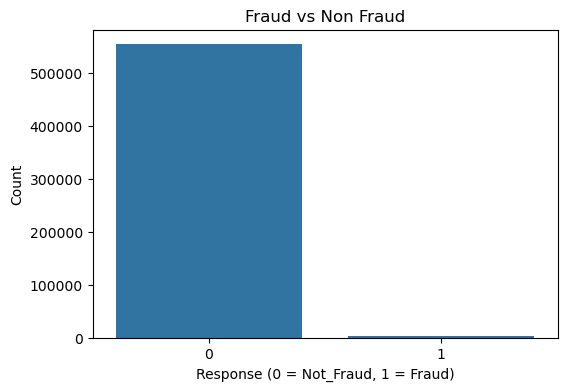


Target Class Distribution (in %):
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


In [20]:
# Check target variable distribution
df['is_fraud'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud',data=df)
plt.title("Fraud vs Non Fraud")
plt.xlabel("Response (0 = Not_Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

print("\nTarget Class Distribution (in %):")
print(df['is_fraud'].value_counts(normalize=True) * 100)   #....Analyzing the Target Variable 'is_fraud'
                                                                # Plotting the distribution of the target to check for class imbalance
                                                                # Important for selecting appropriate models and evaluation metrics

#Use Case: We Understand Imblance Problem

In [21]:
# Check unique values in each column (to identify categorical features and cardinality)
print("\nUnique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")   

#use case: helps to plan Encoding Strategy
#Purpose: 
    #Identify High-cardinality columns and Identify Potential ID columns


Unique values in each column:
merchant: 693 unique values
category: 14 unique values
amt: 37256 unique values
gender: 2 unique values
city: 849 unique values
state: 50 unique values
zip: 912 unique values
lat: 910 unique values
long: 910 unique values
city_pop: 835 unique values
job: 478 unique values
unix_time: 544760 unique values
merch_lat: 546490 unique values
merch_long: 551770 unique values
is_fraud: 2 unique values
year: 1 unique values
month: 7 unique values
day: 31 unique values
hour: 24 unique values
age: 81 unique values
night_transaction: 2 unique values


In [22]:
df.nunique()

merchant                693
category                 14
amt                   37256
gender                    2
city                    849
state                    50
zip                     912
lat                     910
long                    910
city_pop                835
job                     478
unix_time            544760
merch_lat            546490
merch_long           551770
is_fraud                  2
year                      1
month                     7
day                      31
hour                     24
age                      81
night_transaction         2
dtype: int64

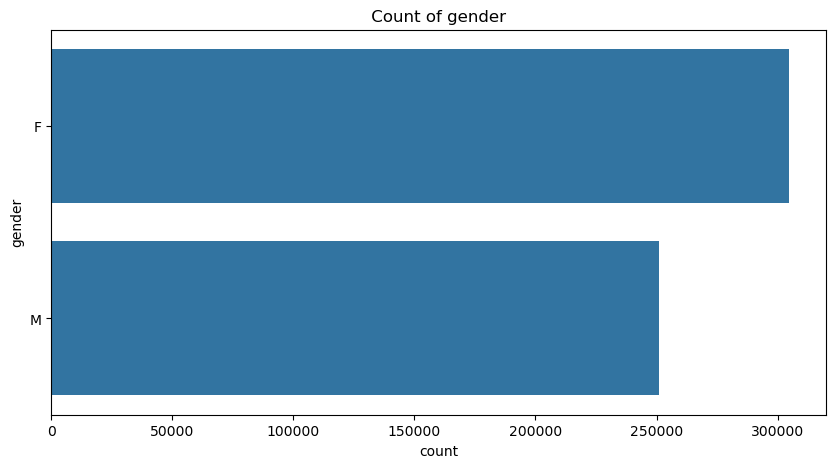

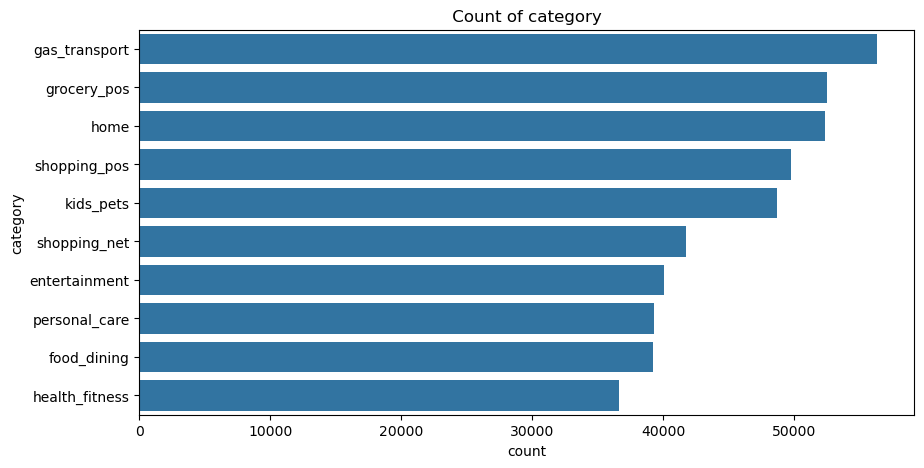

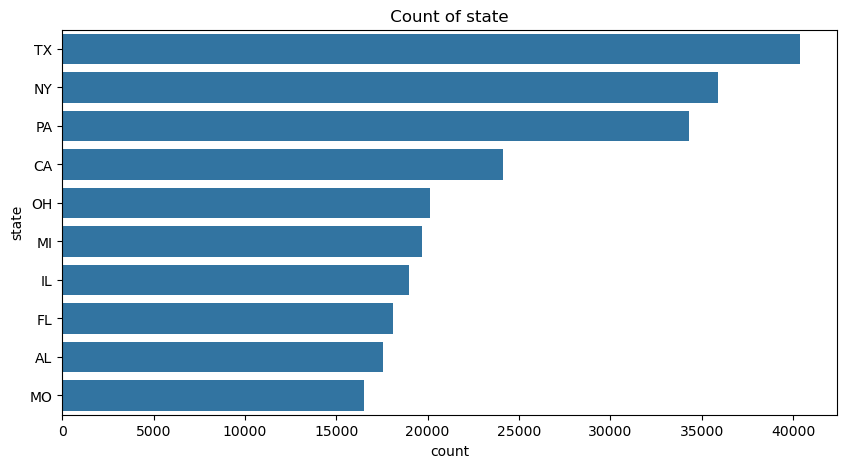

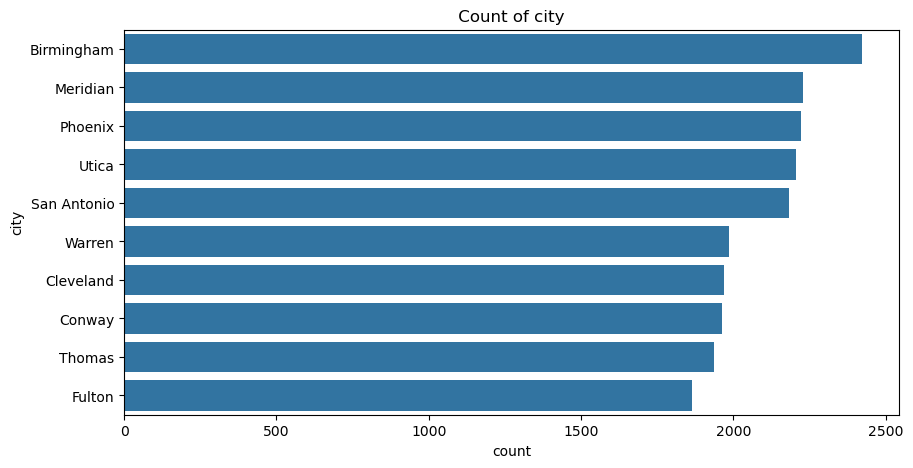

In [23]:
categorical_features = ['gender', 'category','state', 'city']
for col in categorical_features:
    plt.figure(figsize=(10,5))
    sns.countplot(y = df[col], order=df[col].value_counts().index[:10])
    plt.title(f" Count of {col} ")
    plt.show()

#Use Case:
#Understand category frequencies.


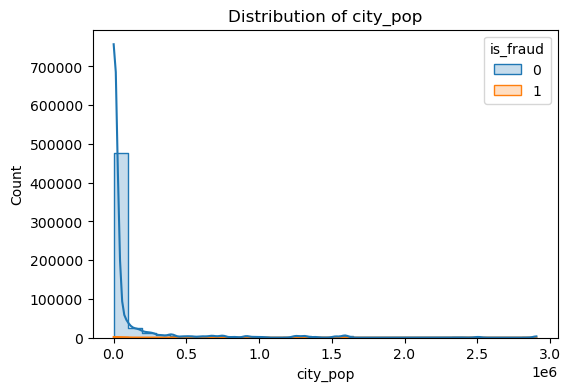

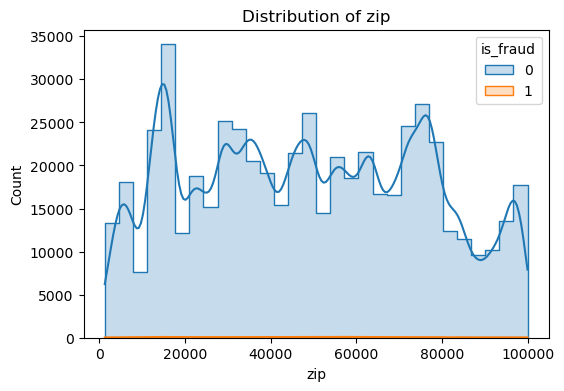

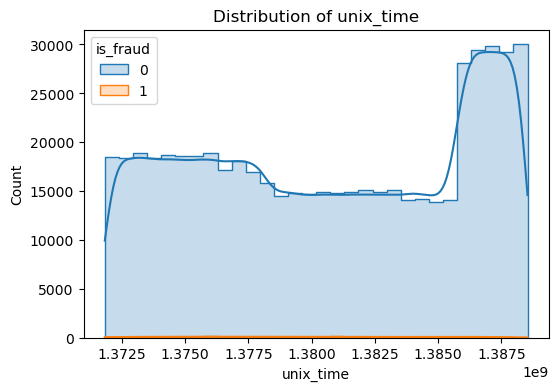

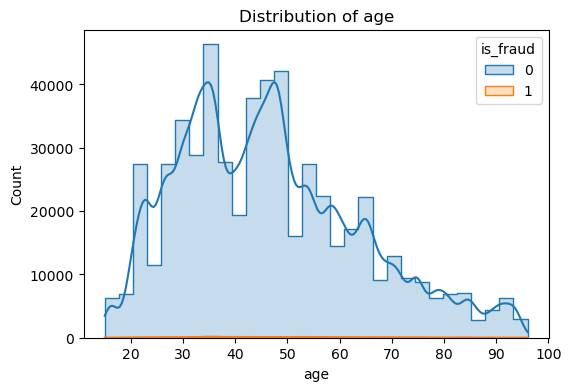

In [24]:
num_features = [
    'city_pop',
    'zip',
    'unix_time',
    'age'
]
for col in num_features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        hue='is_fraud',
        element='step'
    )

    plt.title(f"Distribution of {col}")

    plt.show()
# Interpretation: 
#Most customers belong to low/medium population cities. Transactions are distributed across multiple 
# geographical regions, suggesting broad customer coverage and possible location-based fraud patterns.
# Transaction activity varies significantly across time periods, indicating temporal patterns that may influence fraud detection.
# Middle-aged customers perform most transactions

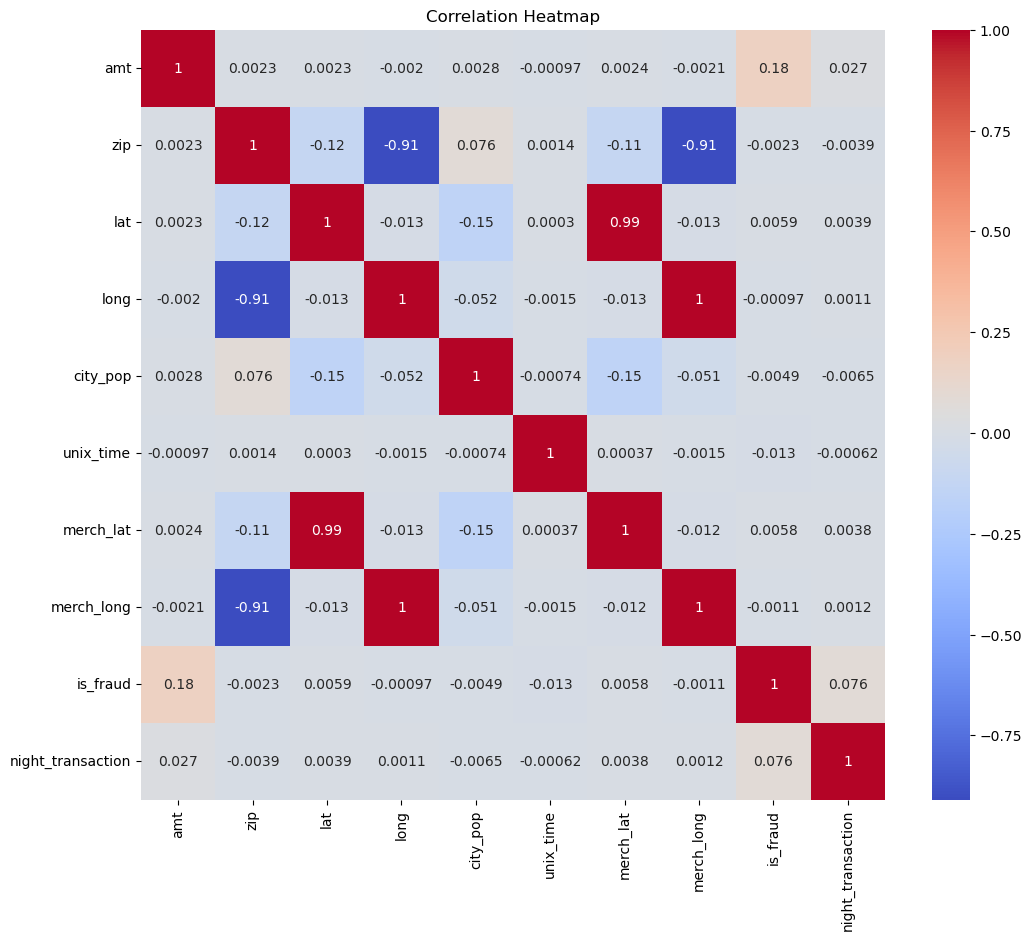

In [25]:
# Step 2.7: Correlation Heatmap (Only for numeric)
corr = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Correlation Heatmap
# Shows correlation between numerical variables
# Not very meaningful in this case due to mostly categorical features, but still useful to visualize

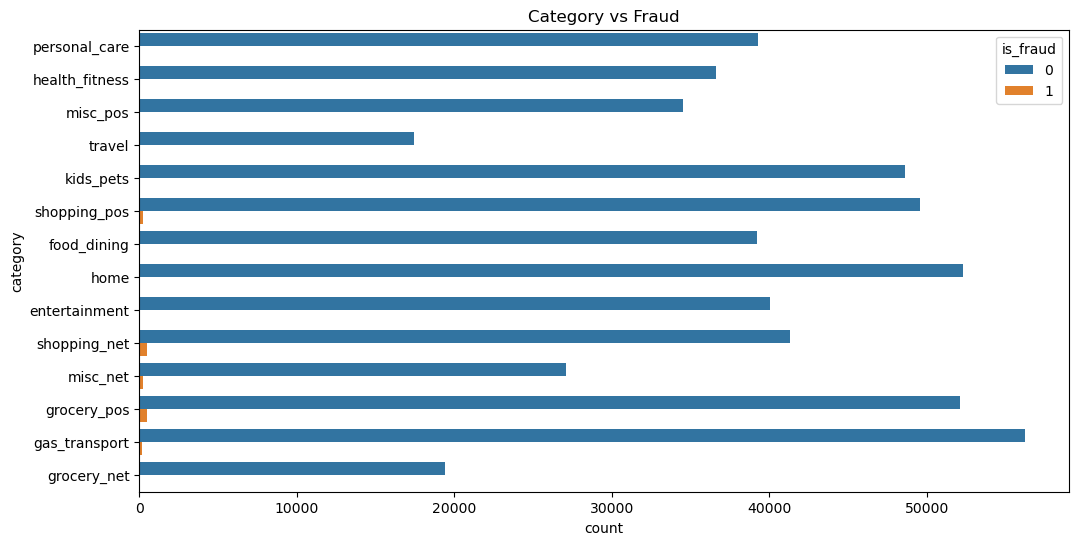

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='category',
    hue='is_fraud',
    data=df
)

plt.title("Category vs Fraud")

plt.show()
#Purpose:
#Find categories with highest fraud rate.

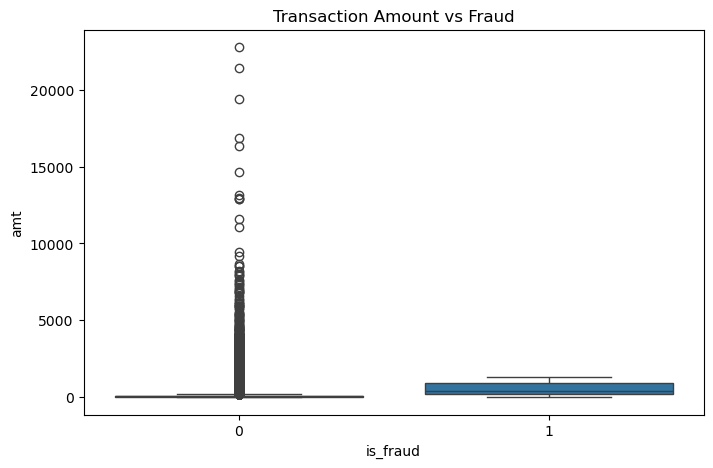

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='amt',
    data=df
)

plt.title("Transaction Amount vs Fraud")

plt.show()
# Interpretations
#Fraud transactions usually have different amount patterns.

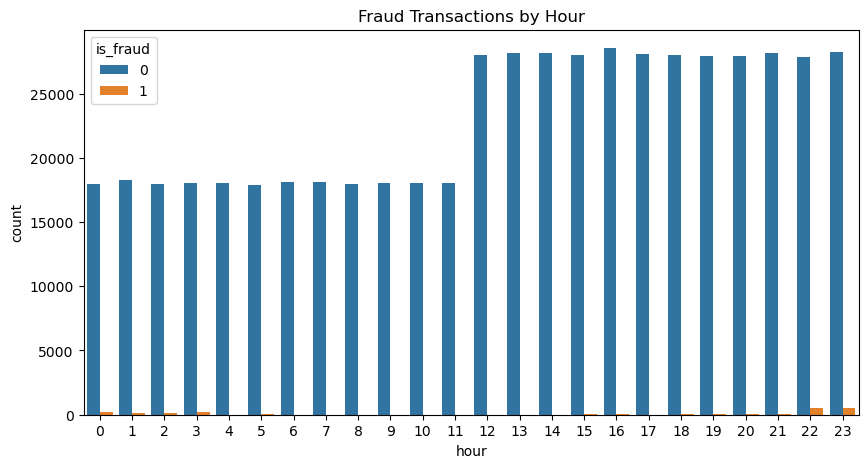


Peak fraud hours:
hour
22    1.937438
23    1.868185
3     1.065993
0     1.035641
2     0.926130
Name: is_fraud, dtype: float64


In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='hour',
    hue='is_fraud',
    data=df
)

plt.title("Fraud Transactions by Hour")

plt.show()
hourly_fraud = df.groupby('hour')['is_fraud'].mean() * 100
print("\nPeak fraud hours:")
print(hourly_fraud.sort_values(ascending=False).head(5))

#Interpretation
#Frauds often occur at unusual hours like at the late night and at early morning.

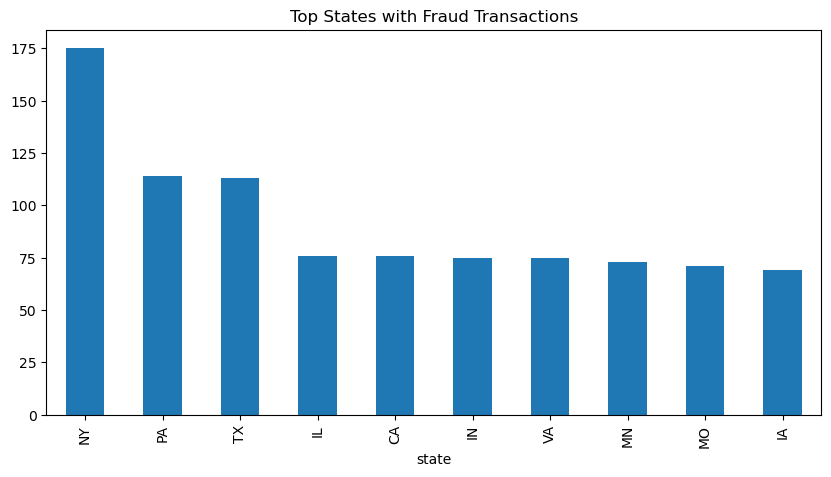

In [29]:
fraud_state = df.groupby('state')['is_fraud'].sum().sort_values(ascending=False)

fraud_state.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top States with Fraud Transactions")

plt.show()
# Interpretation: State like New York (NY) and Pennsylvania (PA) shows the highest sum of fraud transactions

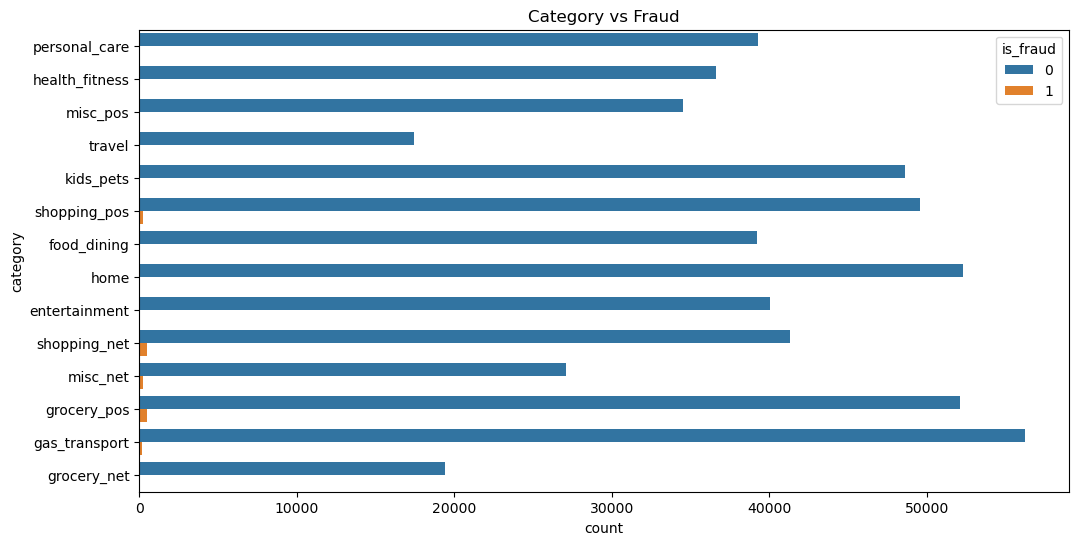


Fraud Rate by Category:
               sum  count  fraud_rate
category                             
shopping_net   506  41779        1.21
misc_net       267  27367        0.98
grocery_pos    485  52553        0.92
shopping_pos   213  49791        0.43
gas_transport  154  56370        0.27
travel          40  17449        0.23
grocery_net     41  19426        0.21
misc_pos        72  34574        0.21
personal_care   70  39327        0.18
entertainment   59  40104        0.15


In [30]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='category',
    hue='is_fraud',
    data=df
)

plt.title("Category vs Fraud")

plt.show()
# Interpretation: categories like shopping_net, grocery_pos, shoppping_net with highest fraud rate.

fraud_by_category = df.groupby('category')['is_fraud'].agg(['sum', 'count'])
fraud_by_category['fraud_rate'] = (fraud_by_category['sum'] / fraud_by_category['count'] * 100).round(2)
fraud_by_category = fraud_by_category.sort_values('fraud_rate', ascending=False)
print("\nFraud Rate by Category:")
print(fraud_by_category.head(10))

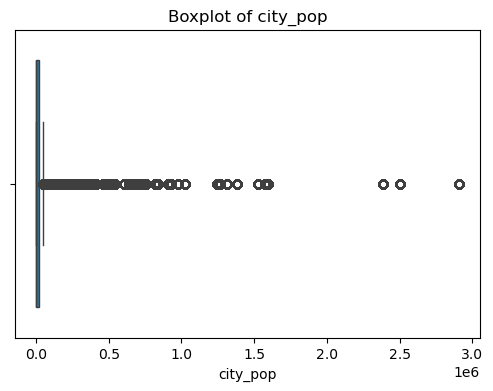

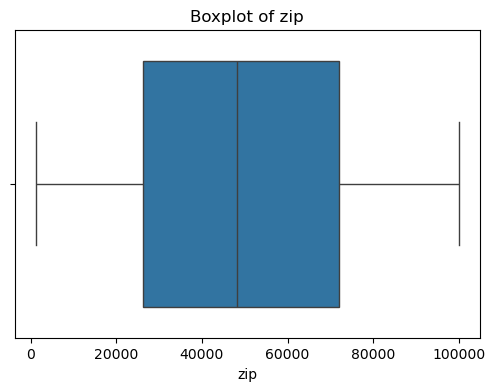

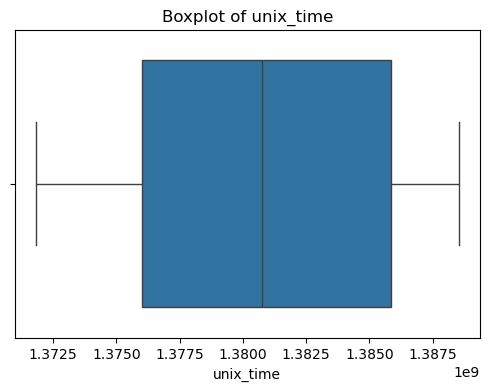

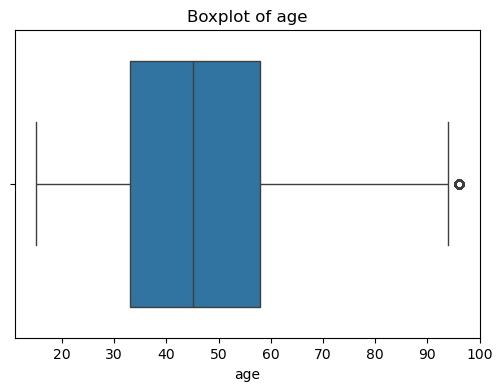

In [32]:
for col in num_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

#Detect abnormal transaction amounts.
# Interpretation: 1. The distribution is highly right-skewed. Most customers belong to small or medium-sized cities.
# 2. ZIP codes are well distributed. No extreme values detected.
# 3.Transaction timestamps cover the entire study period. No abnormal transaction times detected.
# 4.Majority of customers are middle-aged. Very elderly customers represent a small portion of the dataset.

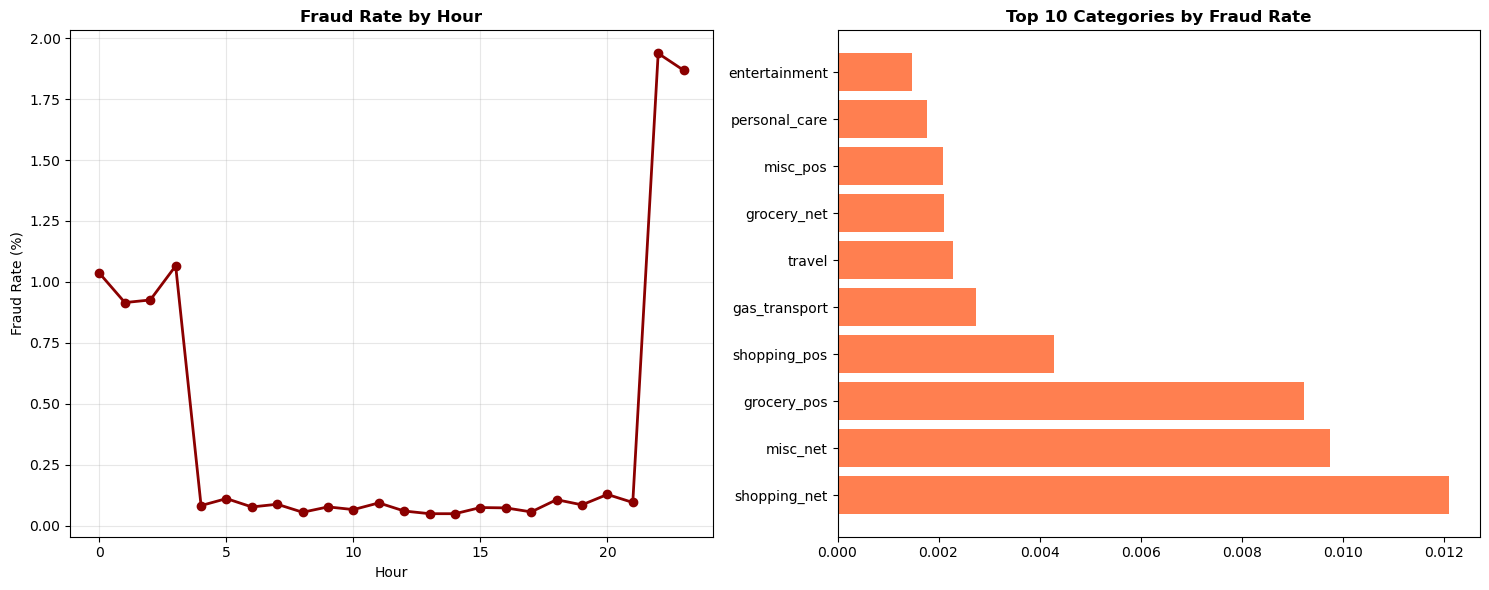

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Fraud by hour
fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
axes[0].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', color='darkred', linewidth=2)
axes[0].set_title('Fraud Rate by Hour', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].grid(alpha=0.3)

# Category fraud rate
fraud_by_cat = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
axes[1].barh(fraud_by_cat.index[:10], fraud_by_cat.values[:10], color='coral')
axes[1].set_title('Top 10 Categories by Fraud Rate', fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretation:
# Financial institutions can implement stricter monitoring and real-time fraud detection mechanisms during high-risk hours to minimize fraudulent activities.
# Banks and payment service providers can apply category-specific fraud prevention strategies, such as enhanced authentication and transaction monitoring for high-risk merchant categories.

## EDA Summary:
- Dataset contains transaction information for credit card users.
- No significant missing and duplicate values were observed.
- Target variable is_fraud is highly imbalanced. Only ~0.5% fraudulent transactions
- Transaction amount (amt) contains outliers.
- Key predictors that influence Fraud Transactions include:
  - Fraud transactions are concentrated in certain merchant categories.
  - Fraud occurrence varies across states.
  - Fraudulent transactions tend to occur more frequently during specific hours.
- Feature engineering on transaction time generated useful variables such as hour, month, and age.
- Correlation between numerical features is generally low.
- **Key Fraud Indicators**: Transaction amount, time, category, location

## Scaling and Encoding

In [17]:
# Step 1: Separate Features and Target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [18]:
# Step 2: Identify Numerical and Categorical Columns
num_cols = X.select_dtypes([int,float])

cat_cols = X.select_dtypes(object)
print("Numerical Columns:")
print(num_cols)

print("Categorical Columns:")
print(cat_cols)

Numerical Columns:
           amt    zip      lat      long  city_pop   unix_time  merch_lat  \
0         2.86  29209  33.9659  -80.9355    333497  1371816865  33.986391   
1        29.84  84002  40.3207 -110.4360       302  1371816873  39.450498   
2        41.28  11710  40.6729  -73.5365     34496  1371816893  40.495810   
3        60.05  32780  28.5697  -80.8191     54767  1371816915  28.812398   
4         3.19  49632  44.2529  -85.0170      1126  1371816917  44.959148   
...        ...    ...      ...       ...       ...         ...        ...   
555714   43.77  63453  40.4931  -91.8912       519  1388534347  39.946837   
555715  111.84  77566  29.0393  -95.4401     28739  1388534349  29.661049   
555716   86.88  99323  46.1966 -118.9017      3684  1388534355  46.658340   
555717    7.99  83643  44.6255 -116.4493       129  1388534364  44.470525   
555718   38.13  73034  35.6665  -97.4798    116001  1388534374  36.210097   

        merch_long  year  month  day  hour  age  night_t

In [19]:
# Step 3: Encode Categorical Variables
# Label Encoding can be applied
from sklearn.preprocessing import LabelEncoder
encoders = {}
df_encoded = df.copy()
for col in cat_cols:
    le = LabelEncoder()                                                          #......# ML algorithms don't work with text, so we convert these into numbers using Label Encoding.
    df_encoded[col] = le.fit_transform(X[col])
    encoders[col] = le
# One-Hot Encoding was not used because the dataset contains high-cardinality features such as merchant, city, and job, which would create a 
# large number of additional columns. This would increase dimensionality, memory usage, training time, and the risk of overfitting. 
# Therefore, Label Encoding was chosen as a more efficient preprocessing technique for the fraud detection model. 

#Use Case:We are understanding ML Algorithms require Numerical input
#we are choosing the right encoding based on variable Cardinality

In [20]:
df_encoded

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,...,unix_time,merch_lat,merch_long,is_fraud,year,month,day,hour,age,night_transaction
0,319,10,2.86,1,157,39,29209,33.9659,-80.9355,333497,...,1371816865,33.986391,-81.200714,0,2020,6,21,12,52,0
1,591,10,29.84,0,16,43,84002,40.3207,-110.4360,302,...,1371816873,39.450498,-109.960431,0,2020,6,21,12,30,0
2,611,5,41.28,0,61,33,11710,40.6729,-73.5365,34496,...,1371816893,40.495810,-74.196111,0,2020,6,21,12,50,0
3,222,9,60.05,1,764,8,32780,28.5697,-80.8191,54767,...,1371816915,28.812398,-80.883061,0,2020,6,21,12,33,0
4,292,13,3.19,1,247,21,49632,44.2529,-85.0170,1126,...,1371816917,44.959148,-85.884734,0,2020,6,21,12,65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,507,5,43.77,1,443,23,63453,40.4931,-91.8912,519,...,1388534347,39.946837,-91.333331,0,2020,12,31,23,54,1
555715,264,7,111.84,1,401,42,77566,29.0393,-95.4401,28739,...,1388534349,29.661049,-96.186633,0,2020,12,31,23,21,1
555716,496,7,86.88,0,104,46,99323,46.1966,-118.9017,3684,...,1388534355,46.658340,-119.715054,0,2020,12,31,23,39,1
555717,75,13,7.99,1,476,12,83643,44.6255,-116.4493,129,...,1388534364,44.470525,-117.080888,0,2020,12,31,23,55,1


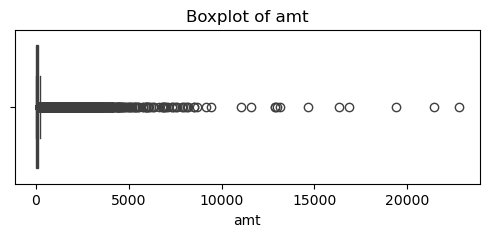

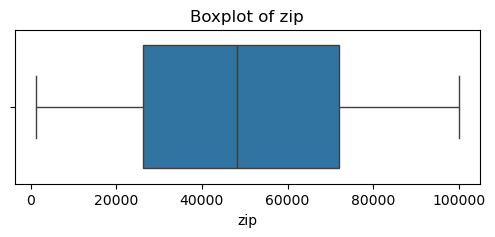

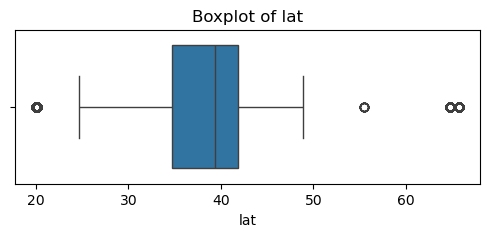

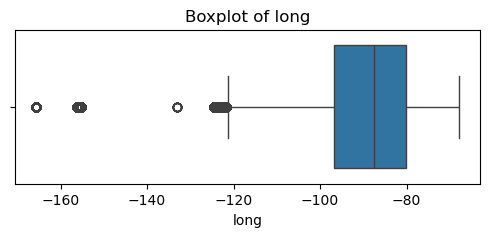

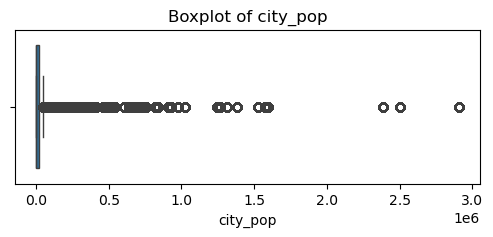

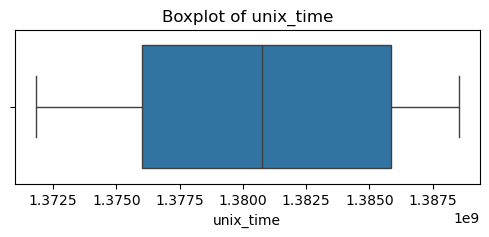

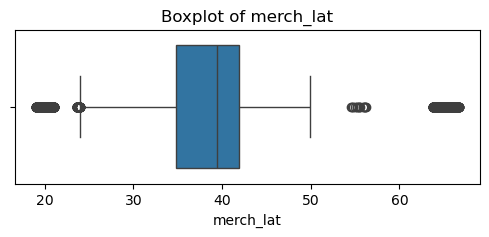

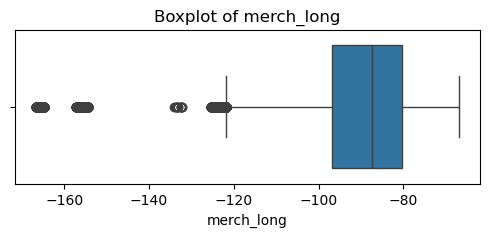

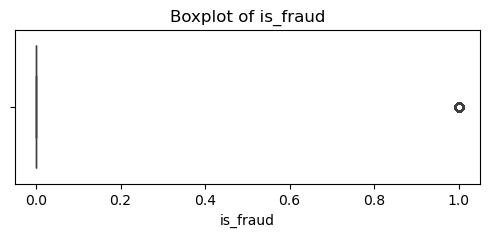

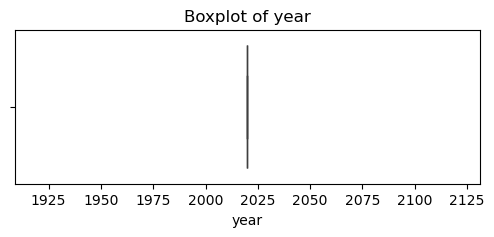

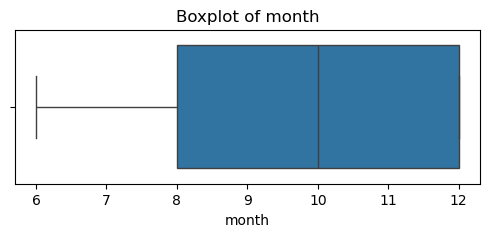

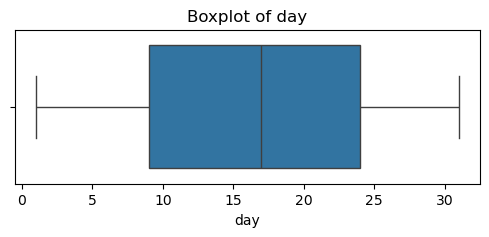

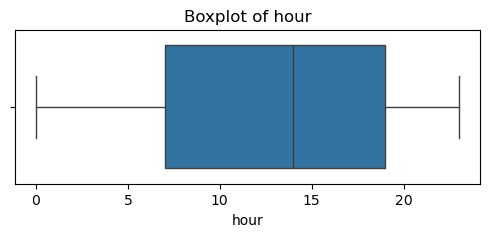

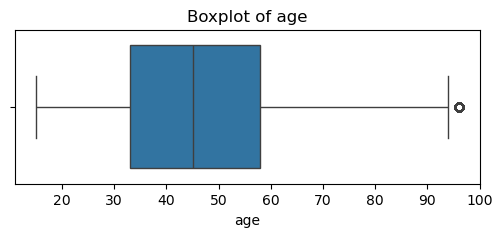

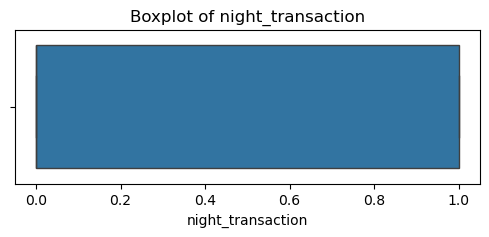

In [24]:
# Outlier Check (for numerical features)
numerical_cols = df.select_dtypes([int, float])

for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [21]:
# Scale Numerical Columns
# Standardization improves model performance by giving all features equal importance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    'amt',
    'city_pop',
    'lat',
    'long',
    'merch_lat',
    'merch_long',
    'age',
]

df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])
# Features like amt, city_pop, lat, long, merch_lat, merch_long, age are the continuous numerical features which have very different ranges.
# Scaling transforms them to a common scale (mean = 0, std = 1) using StandardScaler.
# This is especially important for distance-based algorithms and to improve model convergence.

#Use case:We Know importance of scale for certain models(eg.SVM,KNN)

In [22]:
df_encoded

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,...,unix_time,merch_lat,merch_long,is_fraud,year,month,day,hour,age,night_transaction
0,319,10,-0.424463,1,157,39,29209,-0.904377,0.677451,0.816521,...,1371816865,-0.894145,0.657586,0,2020,6,21,12,0.307935,0
1,591,10,-0.252337,0,16,43,84002,0.351182,-1.472454,-0.292685,...,1371816873,0.178126,-1.436610,0,2020,6,21,12,-0.955089,0
2,611,5,-0.179353,0,61,33,11710,0.420768,1.216667,-0.178853,...,1371816893,0.383257,1.167640,0,2020,6,21,12,0.193114,0
3,222,9,-0.059605,1,764,8,32780,-1.970539,0.685934,-0.111371,...,1371816915,-1.909485,0.680717,0,2020,6,21,12,-0.782859,0
4,292,13,-0.422358,1,247,21,49632,1.128092,0.380004,-0.289942,...,1371816917,1.259139,0.316510,0,2020,6,21,12,1.054267,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,507,5,-0.163467,1,443,23,63453,0.385244,-0.120967,-0.291963,...,1388534347,0.275527,-0.080241,0,2020,12,31,23,0.422755,1
555715,264,7,0.270803,1,401,42,77566,-1.877757,-0.379599,-0.198018,...,1388534349,-1.742946,-0.433644,0,2020,12,31,23,-1.471781,1
555716,496,7,0.111564,0,104,46,99323,1.512121,-2.089408,-0.281427,...,1388534355,1.592587,-2.146912,0,2020,12,31,23,-0.438398,1
555717,75,13,-0.391735,1,476,12,83643,1.201709,-1.910685,-0.293261,...,1388534364,1.163252,-1.955100,0,2020,12,31,23,0.480165,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   merchant           555719 non-null  object 
 1   category           555719 non-null  object 
 2   amt                555719 non-null  float64
 3   gender             555719 non-null  object 
 4   city               555719 non-null  object 
 5   state              555719 non-null  object 
 6   zip                555719 non-null  int64  
 7   lat                555719 non-null  float64
 8   long               555719 non-null  float64
 9   city_pop           555719 non-null  int64  
 10  job                555719 non-null  object 
 11  unix_time          555719 non-null  int64  
 12  merch_lat          555719 non-null  float64
 13  merch_long         555719 non-null  float64
 14  is_fraud           555719 non-null  int64  
 15  year               555719 non-null  int32  
 16  mo

## Train Test Split

In [23]:
# Step 3.3: Split the Dataset into Train and Test
# We split data to evaluate model performance on unseen data (validation)

from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['is_fraud'])
y = df_encoded['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(     #....# We split the data into training (80%) and testing (20%) sets using train_test_split.
X, y, test_size=0.2, random_state=42, stratify=y              # 'stratify=y' ensures that both train and test have the same proportion of target classes (balanced).
)                                                             # This helps to evaluate how the model generalizes to unseen data.


#Use Case:We Understand modle Validation and generalization

In [24]:
X

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,year,month,day,hour,age,night_transaction
0,319,10,-0.424463,1,157,39,29209,-0.904377,0.677451,0.816521,275,1371816865,-0.894145,0.657586,2020,6,21,12,0.307935,0
1,591,10,-0.252337,0,16,43,84002,0.351182,-1.472454,-0.292685,392,1371816873,0.178126,-1.436610,2020,6,21,12,-0.955089,0
2,611,5,-0.179353,0,61,33,11710,0.420768,1.216667,-0.178853,259,1371816893,0.383257,1.167640,2020,6,21,12,0.193114,0
3,222,9,-0.059605,1,764,8,32780,-1.970539,0.685934,-0.111371,407,1371816915,-1.909485,0.680717,2020,6,21,12,-0.782859,0
4,292,13,-0.422358,1,247,21,49632,1.128092,0.380004,-0.289942,196,1371816917,1.259139,0.316510,2020,6,21,12,1.054267,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,507,5,-0.163467,1,443,23,63453,0.385244,-0.120967,-0.291963,460,1388534347,0.275527,-0.080241,2020,12,31,23,0.422755,1
555715,264,7,0.270803,1,401,42,77566,-1.877757,-0.379599,-0.198018,198,1388534349,-1.742946,-0.433644,2020,12,31,23,-1.471781,1
555716,496,7,0.111564,0,104,46,99323,1.512121,-2.089408,-0.281427,294,1388534355,1.592587,-2.146912,2020,12,31,23,-0.438398,1
555717,75,13,-0.391735,1,476,12,83643,1.201709,-1.910685,-0.293261,58,1388534364,1.163252,-1.955100,2020,12,31,23,0.480165,1


In [25]:
y.value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [26]:
# Align train and test sets (fills missing columns with 0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

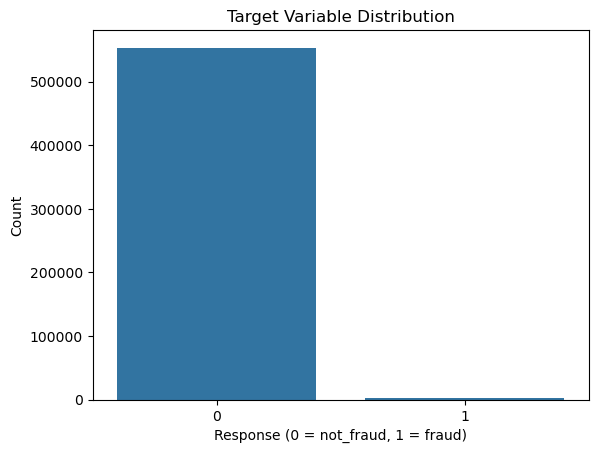


Target Class Distribution (in %):
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


In [34]:
# Check target variable distribution
sns.countplot(x='is_fraud', data=df)
plt.title("Target Variable Distribution")
plt.xlabel("Response (0 = not_fraud, 1 = fraud)")
plt.ylabel("Count")
plt.show()

print("\nTarget Class Distribution (in %):")
print(df['is_fraud'].value_counts(normalize=True) * 100)   #....Analyzing the Target Variable 'is_fraud'
                                                                # Plotting the distribution of the target to check for class imbalance
                                                                # Important for selecting appropriate models and evaluation metrics

#Use Case: We Understand Imblance Problem

# SMOTE

In [27]:
# Handling Imbalanced Dataset using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_res.value_counts())

Before SMOTE:
is_fraud
0    442859
1      1716
Name: count, dtype: int64

After SMOTE:
is_fraud
0    442859
1    442859
Name: count, dtype: int64


# Model Building

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

## Logistic Regression

In [41]:
lr = LogisticRegression(penalty = "l2", solver = "lbfgs", random_state = 42,max_iter=1000)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC Score:", round(roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),2) * 100, "%")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.52      0.69    110715
           1       0.00      0.53      0.01       429

    accuracy                           0.52    111144
   macro avg       0.50      0.53      0.35    111144
weighted avg       0.99      0.52      0.68    111144

ROC AUC Score: 53.0 %


## Decision Tree

In [42]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt))
print("ROC AUC Score:", round(roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]), 2) * 100, "%")

Decision Tree Results:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    110715
           1       0.28      0.81      0.42       429

    accuracy                           0.99    111144
   macro avg       0.64      0.90      0.71    111144
weighted avg       1.00      0.99      0.99    111144

ROC AUC Score: 90.0 %


### Hypertuning in Decision Tree

In [37]:
from sklearn.model_selection import GridSearchCV
# Define parameters
dt_params = {
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

# Model
dt = DecisionTreeClassifier(random_state=42)

# Grid search
grid_dt = GridSearchCV(dt, dt_params, cv= 5, scoring = 'roc-auc',n_jobs= -1 ,verbose = 3)
grid_dt.fit(X_train_res, y_train_res)

# Best model
best_dt = grid_dt.best_estimator_

# Evaluation
y_pred_dt = best_dt.predict(X_test)
print("Decision Tree After Tuning:")
print(classification_report(y_test, y_pred_dt))
print("ROC AUC Score:", roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1]))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END max_depth=10, min_samples_leaf=1, min_samples_split=2;, score=0.951 total time=  10.5s
[CV 2/5] END max_depth=10, min_samples_leaf=1, min_samples_split=2;, score=0.951 total time=  10.5s
[CV 3/5] END max_depth=10, min_samples_leaf=1, min_samples_split=2;, score=0.952 total time=  10.6s
[CV 4/5] END max_depth=10, min_samples_leaf=1, min_samples_split=2;, score=0.951 total time=  10.5s
[CV 5/5] END max_depth=10, min_samples_leaf=1, min_samples_split=2;, score=0.952 total time=  10.6s
[CV 1/5] END max_depth=10, min_samples_leaf=1, min_samples_split=5;, score=0.951 total time=  10.5s
[CV 2/5] END max_depth=10, min_samples_leaf=1, min_samples_split=5;, score=0.951 total time=  10.6s
[CV 3/5] END max_depth=10, min_samples_leaf=1, min_samples_split=5;, score=0.952 total time=  10.4s
[CV 4/5] END max_depth=10, min_samples_leaf=1, min_samples_split=5;, score=0.951 total time=  10.5s
[CV 5/5] END max_depth=10, min_samples_

In [38]:
grid_dt.best_params_

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [39]:
grid_dt.best_score_

np.float64(0.9933240609689991)

## Hypertuned Decision Tree

In [78]:
DT_hypertuned = DecisionTreeClassifier(max_depth = 20, min_samples_split = 5, min_samples_leaf = 2, random_state = 42)
DT_hypertuned.fit(X_train_res, y_train_res)
ypred_1 = DT_hypertuned.predict(X_train_res)
print(f"Hypertuned Training Accuracy is: {round(accuracy_score(ypred_1, y_train_res), 2)*100}%")
ypred = DT_hypertuned.predict(X_test)
print(f"Hypertuned Test Accuracy is: {round(accuracy_score(ypred, y_test), 2)*100}%")

Hypertuned Training Accuracy is: 99.0%
Hypertuned Test Accuracy is: 98.0%


## Random Forest

In [43]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.70      0.78      0.74       429

    accuracy                           1.00    111144
   macro avg       0.85      0.89      0.87    111144
weighted avg       1.00      1.00      1.00    111144

ROC AUC Score: 0.9890000333707147


## Hypertuning in Random Forest

In [40]:
from sklearn.model_selection import GridSearchCV
# Parameter Grid
rf_params = {
    'n_estimators': [100, 130],
    'max_depth': [20, None]
}

# Base Model
rf = RandomForestClassifier(
    random_state=42
)

# Grid Search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring= 'roc_auc',
    n_jobs = -1,
    cv=3, verbose = 3
)

# Fit
grid_rf.fit(X_train_res, y_train_res)

# Best Model
best_rf = grid_rf.best_estimator_

# Best Parameters
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_rf.best_score_)

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# Evaluation
print("\nRandom Forest After Tuning:")
print(classification_report(y_test, y_pred_rf))

print("ROC AUC Score:",
      roc_auc_score(y_test, y_prob_rf))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV 1/3] END ....max_depth=20, n_estimators=100;, score=0.995 total time= 1.5min
[CV 2/3] END ....max_depth=20, n_estimators=100;, score=0.995 total time= 1.4min
[CV 3/3] END ....max_depth=20, n_estimators=100;, score=0.996 total time= 1.4min
[CV 1/3] END ....max_depth=20, n_estimators=130;, score=0.995 total time= 1.9min
[CV 2/3] END ....max_depth=20, n_estimators=130;, score=0.996 total time= 1.9min
[CV 3/3] END ....max_depth=20, n_estimators=130;, score=0.996 total time= 1.9min
[CV 1/3] END ..max_depth=None, n_estimators=100;, score=0.999 total time= 1.6min
[CV 2/3] END ..max_depth=None, n_estimators=100;, score=0.999 total time= 1.7min
[CV 3/3] END ..max_depth=None, n_estimators=100;, score=0.999 total time= 1.9min
[CV 1/3] END ..max_depth=None, n_estimators=130;, score=0.999 total time= 2.2min
[CV 2/3] END ..max_depth=None, n_estimators=130;, score=0.999 total time= 2.3min
[CV 3/3] END ..max_depth=None, n_estimators=130;,

In [41]:
df_encoded.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud', 'year', 'month', 'day', 'hour', 'age', 'night_transaction'],
      dtype='object')

In [42]:
# Remove '<', '>', '[', ']', and ensure all names are strings
X_train_res.columns = X_train_res.columns.astype(str).str.replace(r'[<>\[\]]', '', regex=True)
X_test.columns = X_test.columns.astype(str).str.replace(r'[<>\[\]]', '', regex=True)

In [43]:
X_train

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,year,month,day,hour,age,night_transaction
219591,644,0,-0.326279,1,444,21,48636,1.196690,0.432759,-0.290814,201,1378557464,1.017490,0.377556,2020,9,7,12,1.800599,0
385043,87,4,0.785585,0,553,26,28659,-0.462636,0.663378,-0.223335,126,1384774507,-0.331894,0.730287,2020,11,18,11,-0.610628,0
270811,103,2,-0.162638,1,407,31,87540,-0.614888,-1.144865,-0.290618,366,1380454669,-0.741237,-1.211873,2020,9,29,11,0.537575,0
270180,475,8,-0.434735,1,719,24,39665,-1.362873,0.003733,-0.289709,258,1380431862,-1.515761,-0.027521,2020,9,29,5,0.882036,1
551235,75,13,-0.378975,1,69,33,12410,0.697593,1.149876,-0.292369,356,1388422195,0.739490,1.113564,2020,12,30,16,2.432111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379494,603,6,-0.300377,1,762,44,22853,0.020617,0.835142,-0.279153,472,1384604813,-0.028504,0.890235,2020,11,16,12,0.652396,0
223907,642,1,-0.001932,1,832,15,67232,-0.178560,-0.505771,1.070054,215,1378668210,-0.004066,-0.577777,2020,9,8,19,-0.668039,0
536871,256,11,-0.389949,0,667,34,43070,0.330456,0.457188,-0.293248,351,1388189926,0.347622,0.482254,2020,12,28,0,1.111677,1
353653,41,6,-0.013798,0,72,39,29817,-1.023200,0.652942,-0.277335,441,1383592948,-0.918830,0.597773,2020,11,4,19,0.422755,0


## Bagging

In [62]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train_res, y_train_res)

y_pred_bag = bagging.predict(X_test)

In [65]:
y_proba = bagging.predict_proba(X_test)[:, 1]
print(classification_report(y_pred_bag, y_test))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110331
           1       0.81      0.43      0.56       813

    accuracy                           1.00    111144
   macro avg       0.90      0.71      0.78    111144
weighted avg       0.99      1.00      0.99    111144

ROC AUC Score: 0.9765782637480239


## Boosting

## Gradient Boosting

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train_res, y_train_res)

y_pred_gb = gb.predict(X_test)

In [68]:
y_proba = gb.predict_proba(X_test)[:, 1]
print(classification_report(y_pred_gb, y_test))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98    106849
           1       0.89      0.09      0.16      4295

    accuracy                           0.96    111144
   macro avg       0.93      0.54      0.57    111144
weighted avg       0.96      0.96      0.95    111144

ROC AUC Score: 0.9786246359881369


## XG Boosting (Extreme Gradient)

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Train the model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)

# Predictions
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Accuracy score is:", accuracy_score(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.52      0.92      0.66       429

    accuracy                           1.00    111144
   macro avg       0.76      0.96      0.83    111144
weighted avg       1.00      1.00      1.00    111144

ROC AUC Score: 0.9968683110533808
Accuracy score is: 0.9964190599582523


## KNN - k Nearest Neighbors

In [34]:
# Step 1: Scale the data
# KNN is distance-based, so scaling is mandatory for all the columns in X.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_res)

# Predict
y_preds_knn = knn_model.predict(X_test_scaled)
knn_probs = knn_model.predict_proba(X_test)[:, 1]

In [36]:
# Evaluation

print("📊 K-Nearest Neighbors (KNN) Results:")
print("Accuracy:", accuracy_score(y_test, y_preds_knn))
print("ROC AUC Score:", roc_auc_score(y_test, knn_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_preds_knn))
print("Classification Report:\n", classification_report(y_test, y_preds_knn))

📊 K-Nearest Neighbors (KNN) Results:
Accuracy: 0.9904988123515439
ROC AUC Score: 0.5
Confusion Matrix:
 [[109771    944]
 [   112    317]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    110715
           1       0.25      0.74      0.38       429

    accuracy                           0.99    111144
   macro avg       0.63      0.87      0.69    111144
weighted avg       1.00      0.99      0.99    111144



## Gaussian Naive Bayes

In [47]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train
nb_model = GaussianNB()
nb_model.fit(X_train_res, y_train_res)

# Predict
nb_preds = nb_model.predict(X_test)
nb_probs = nb_model.predict_proba(X_test)[:, 1]


# Evaluation
print("Naive Bayes (GaussianNB) Results:")
print("Accuracy:", accuracy_score(y_test, nb_preds)*100)
print("ROC AUC Score:", roc_auc_score(y_test, nb_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, nb_preds))
print("Classification Report:\n", classification_report(y_test, nb_preds))

Naive Bayes (GaussianNB) Results:
Accuracy: 41.578492766141224
ROC AUC Score: 0.5780162783820825
Confusion Matrix:
 [[45910 64805]
 [  127   302]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.41      0.59    110715
           1       0.00      0.70      0.01       429

    accuracy                           0.42    111144
   macro avg       0.50      0.56      0.30    111144
weighted avg       0.99      0.42      0.58    111144



# Model Evaluation

In [50]:

def evaluate_model(y_true, y_pred, y_prob, model_name):
    
    print("="*50)
    print(f"{model_name}")
    print("="*50)

    print(f"Accuracy Score : {accuracy_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC Score  : {roc_auc_score(y_true, y_prob):.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    print("\n")
evaluate_model(y_test,y_pred_lr, lr.predict_proba(X_test)[:,1], "Logistic Regression")
evaluate_model(y_test,y_pred_dt, dt.predict_proba(X_test)[:,1], "Decision Tree")
evaluate_model(y_test,nb_preds, nb_model.predict_proba(X_test)[:,1], "Naive Bayes")
evaluate_model(y_test, y_pred_rf, rf.predict_proba(X_test)[:,1], "Random Forest")
evaluate_model(y_test, y_preds_knn, knn_model.predict_proba(X_test_scaled)[:,1], "KNN")
evaluate_model(y_test,y_pred,xgb.predict_proba(X_test)[:,1],"XGBoost")

Logistic Regression
Accuracy Score : 0.5229
ROC-AUC Score  : 0.5303

Confusion Matrix
[[57888 52827]
 [  202   227]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.52      0.69    110715
           1       0.00      0.53      0.01       429

    accuracy                           0.52    111144
   macro avg       0.50      0.53      0.35    111144
weighted avg       0.99      0.52      0.68    111144



Decision Tree
Accuracy Score : 0.9914
ROC-AUC Score  : 0.8993

Confusion Matrix
[[109839    876]
 [    83    346]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    110715
           1       0.28      0.81      0.42       429

    accuracy                           0.99    111144
   macro avg       0.64      0.90      0.71    111144
weighted avg       1.00      0.99      0.99    111144



Naive Bayes
Accuracy Score : 0.4158
ROC-AUC Score  : 0.5780

Con

In [52]:
results = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Decision Tree",
              "Naive Bayes",
              "Random Forest",
              "KNN",
              "XGBoost"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_preds_knn),
        accuracy_score(y_test, y_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
3,Random Forest,0.997895
5,XGBoost,0.996419
1,Decision Tree,0.991372
4,KNN,0.990499
0,Logistic Regression,0.522880
2,Naive Bayes,0.415785


In [58]:
# Feature Importance Plot
# Extract feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top features
print(feature_importance.head(10))

              Feature  Importance
2                 amt    0.463941
19  night_transaction    0.114403
17               hour    0.091680
1            category    0.059288
11          unix_time    0.040022
9            city_pop    0.025984
18                age    0.023058
16                day    0.019984
5               state    0.018244
7                 lat    0.016757


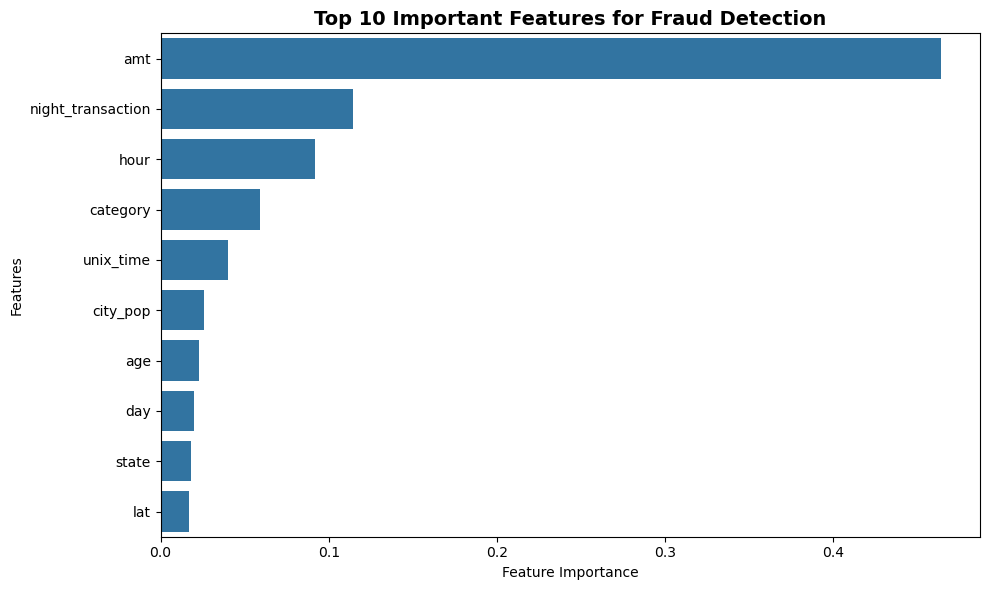

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Important Features for Fraud Detection',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

# Interpretation:
# 1. The feature importance analysis revealed that transaction amount (amt) which is most important for predicting fraud transactions.
# 2. time-related variables (hour, night_transaction, unix_time), merchant information (merchant, category), and geographical features 
# (lat, long, merch_lat, merch_long) were among the most influential predictors of fraudulent transactions. 
# 3. This indicates that both transaction behavior and location-based characteristics play a significant role in detecting credit card fraud.

## Voting Classifier

In [71]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('dt', DecisionTreeClassifier()),
        ('xgb', XGBClassifier(eval_metric='logloss'))
    ],
    voting='soft',
    verbose = 3
)

voting.fit(X_train_res, y_train_res)

y_pred_vote = voting.predict(X_test)

[Voting] ....................... (1 of 3) Processing lr, total=   7.8s
[Voting] ....................... (2 of 3) Processing dt, total=  30.4s
[Voting] ...................... (3 of 3) Processing xgb, total=   6.3s


In [72]:
print("Accuracy Score:", accuracy_score(y_pred_vote, y_test))
y_proba = voting.predict_proba(X_test)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Accuracy Score: 0.9926311811703735
ROC AUC Score: 0.9909457355331899


In [86]:
# Conclusion
# The Random Forest Classifier, after applying SMOTE to handle class imbalance and performing hyperparameter tuning, emerged as the best model 
# for detecting fraudulent credit card transactions. The model achieved an excellent ROC-AUC score of 0.998, demonstrating a strong ability to 
# distinguish between legitimate and fraudulent transactions. The results indicate that the model can help financial institutions 
# identify suspicious transactions more accurately, reduce financial losses, and enhance transaction security in real-world applications.

# Model Deployment

In [ ]:
# Using Random Forest Classifier due to its best accuracy score and roc-auc score for deployment

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
import joblib

joblib.dump(rf, "model.pkl", compress = 3)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [31]:
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [35]:
# Way to get fraud transactions:
fraud_case = df[df['is_fraud']==1][[
    'merchant',
    'category',
    'amt',
    'gender',
    'city',
    'state',
    'zip',
    'lat',
    'long',
    'city_pop',
    'job',
    'unix_time',
    'merch_lat',
    'merch_long',
    'year',
    'month',
    'day',
    'hour',
    'age',
    'night_transaction'
]].iloc[0]

print(fraud_case)

merchant             fraud_Hamill-D'Amore
category                   health_fitness
amt                                 24.84
gender                                  F
city                              Notrees
state                                  TX
zip                                 79759
lat                               31.8599
long                            -102.7413
city_pop                               23
job                        Cytogeneticist
unix_time                      1371852399
merch_lat                       32.575873
merch_long                     -102.60429
year                                 2020
month                                   6
day                                    21
hour                                   22
age                                    51
night_transaction                       1
Name: 1685, dtype: object
